# 02_Preprocessamento - Versão final (entrega)

Notebook completo e passo-a-passo para a **Etapa 2 — Pré-processamento**, pronto para rodar no Google Colab. Substitua `DATA_PATH` pelo caminho do seu CSV no Colab se necessário.

**Observação:** As células que salvam os artefatos finais (`students_clean.csv` e `models/scaler.pkl`) estão comentadas — descomente apenas quando quiser gerar os arquivos finais.

## 0. Bibliotecas e carregamento de dados
Carregue o dataset (faça upload no Colab ou ajuste o caminho).

In [ ]:
# === 0. Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
import joblib
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,5)
sns.set(style='whitegrid')


DATA_PATH = '/content/youtube_views.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (2520, 22)


,video_id,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,...,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
0,VID00197,3,53,589.0,34.0,Sim,720p,Fitness,Português,Não,...,406,9,2804.0,5269,NaN,624,Não,Tarde,Sexta,2219779
1,VID00987,60,95,NaN,17.0,Não,720p,Culinária,Português,Não,...,25,14,9634.0,9448,1679.0,894,Sim,Tarde,Sexta,719904
2,VID01091,47,35,168.0,20.0,Não,1080p,Gaming,Espanhol,Não,...,59,1,6943.0,34028,542.0,540,Não,Manhã,Seg-Qui,1420456
3,VID00388,8,12,260.0,4.0,Sim,1080p,Tecnologia,Português,Sim,...,93,10,9427.0,42695,3096.0,188,Não,Madrugada,Sábado,329746
4,VID02222,56,94,648.0,48.0,Não,720p,Vlogs,Espanhol,Não,...,205,13,2993.0,40761,311.0,957,Não,Manhã,Domingo,984985


## 1. Parte 1 — Valores Faltantes
### 1.1 - Verificação inicial (antes da imputação)

In [ ]:
# Contagem de missing antes
missing_before = df.isna().sum().sort_values(ascending=False)
missing_before[missing_before>0]

,0
tags_count,40
description_length,40
comments_count,40
shares_count,40
channel_age_months,40


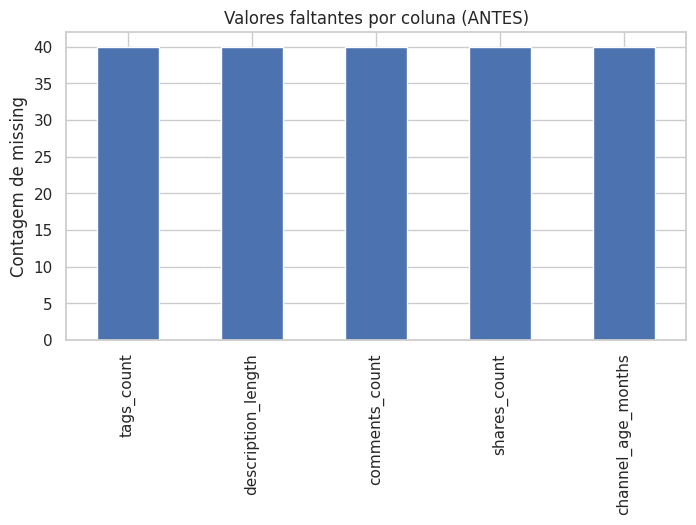

In [ ]:
# Gráfico: missing antes
plt.figure(figsize=(8,4))
missing_before[missing_before>0].plot(kind='bar')
plt.title('Valores faltantes por coluna (ANTES)')
plt.ylabel('Contagem de missing')
plt.show()

### 1.2 - Imputação
Decisão: usar **mediana** para colunas numéricas e **moda** (most_frequent) para colunas categóricas. Salvaremos os imputers para reprodução.

In [ ]:
# Separar colunas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Criar imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit-transform (AVISO: para evitar data leakage em projeto real, fit apenas no treino)
df_num = pd.DataFrame(num_imputer.fit_transform(df[numeric_cols]), columns=numeric_cols, index=df.index)
df_cat = pd.DataFrame(cat_imputer.fit_transform(df[cat_cols]), columns=cat_cols, index=df.index)

# Recombinar (mantendo ordem original)
df_imputed = pd.concat([df_num, df_cat], axis=1)[df.columns]

# Salvar imputers localmente (opcional)
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')

print('Missing total antes:', missing_before.sum())
print('Missing total depois:', df_imputed.isna().sum().sum())
df_imputed.head()

Missing total antes: 200
Missing total depois: 0


,video_id,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,...,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
0,VID00197,3.0,53.0,589.0,34.0,Sim,720p,Fitness,Português,Não,...,406.0,9.0,2804.0,5269.0,2469.5,624.0,Não,Tarde,Sexta,2219779.0
1,VID00987,60.0,95.0,535.0,17.0,Não,720p,Culinária,Português,Não,...,25.0,14.0,9634.0,9448.0,1679.0,894.0,Sim,Tarde,Sexta,719904.0
2,VID01091,47.0,35.0,168.0,20.0,Não,1080p,Gaming,Espanhol,Não,...,59.0,1.0,6943.0,34028.0,542.0,540.0,Não,Manhã,Seg-Qui,1420456.0
3,VID00388,8.0,12.0,260.0,4.0,Sim,1080p,Tecnologia,Português,Sim,...,93.0,10.0,9427.0,42695.0,3096.0,188.0,Não,Madrugada,Sábado,329746.0
4,VID02222,56.0,94.0,648.0,48.0,Não,720p,Vlogs,Espanhol,Não,...,205.0,13.0,2993.0,40761.0,311.0,957.0,Não,Manhã,Domingo,984985.0


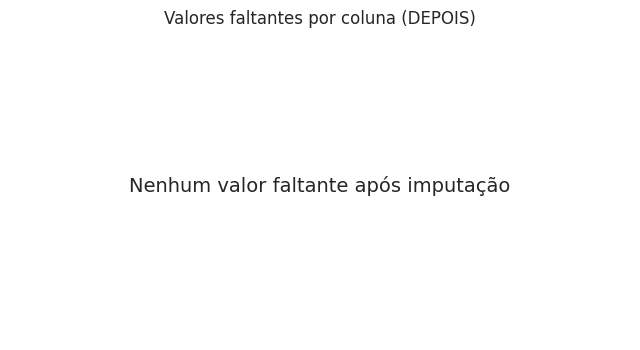

In [ ]:
# Gráfico: missing depois
missing_after = df_imputed.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))

if (missing_after > 0).any():
    missing_after[missing_after > 0].plot(kind='bar')
else:
    plt.text(0.5, 0.5, "Nenhum valor faltante após imputação",
             ha='center', va='center', fontsize=14)
    plt.axis('off')

plt.title('Valores faltantes por coluna (DEPOIS)')
plt.ylabel('Contagem de missing')
plt.show()


**Q1 - A mediana foi escolhida porque:**

É robusta a outliers — o dataset tem muitas colunas com valores extremos (likes, shares, subscribers).

A maioria das distribuições apresentou skewness alta (assimétricas), e a mediana é a medida mais adequada nesses casos.

Evita distorcer os dados quando existe grande variação entre valores.

**Q2 - Para evitar data leakage, é essencial**:

Separar treino e teste antes de aplicar o One-Hot Encoding.

fit no conjunto de treino, apenas transform no teste.

Garantir que novas categorias inesperadas no teste não criem colunas adicionais (usar drop_first=True e manter estrutura fixa).

Nunca usar informações do teste para gerar categorias.

## 2. Parte 2 — Outliers
Detectar outliers com método IQR e aplicar capping (Q1 - 1.5*IQR, Q3 + 1.5*IQR).

In [ ]:
# Função utilitária para limites IQR
def iqr_limits(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

# Relatório de outliers antes
outlier_report = {}
for col in numeric_cols:
    lower, upper = iqr_limits(df_imputed[col])
    outliers = df_imputed[(df_imputed[col] < lower) | (df_imputed[col] > upper)][col]
    outlier_report[col] = {'total_outliers': int(len(outliers)), 'percent': round(len(outliers)/len(df_imputed)*100,3), 'lower': lower, 'upper': upper}

outlier_df = pd.DataFrame(outlier_report).T.sort_values('percent', ascending=False)
outlier_df.head(20)

,total_outliers,percent,lower,upper
total_views,143.0,5.675,-613654.875,2103904.125
channel_subscribers,15.0,0.595,-544537.125,1536069.875
duration_minutes,15.0,0.595,-26.500,89.500
description_length,0.0,0.000,-410.375,1480.625
title_length,0.0,0.000,-36.125,144.875
tags_count,0.0,0.000,-25.500,74.500
channel_age_months,0.0,0.000,-58.500,177.500
avg_upload_frequency_days,0.0,0.000,-14.500,45.500
previous_videos_count,0.0,0.000,-262.500,749.500
comments_count,0.0,0.000,-4586.000,14398.000


Coluna exemplo para boxplot: total_views


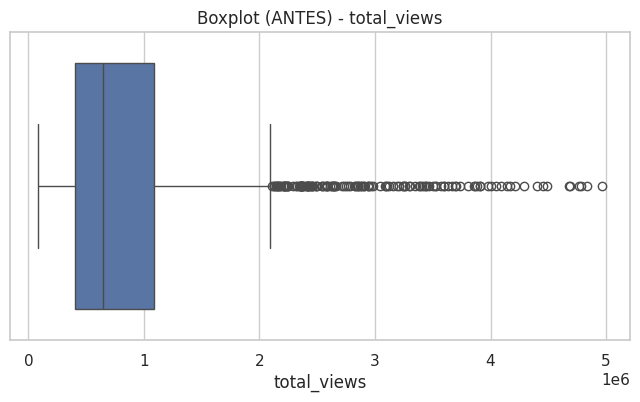

In [ ]:
# Escolher coluna exemplo (com mais outliers) para plot antes/depois
col_example = outlier_df['total_outliers'].idxmax()
print('Coluna exemplo para boxplot:', col_example)

plt.figure(figsize=(8,4))
sns.boxplot(x=df_imputed[col_example])
plt.title(f'Boxplot (ANTES) - {col_example}')
plt.show()

### Aplicar capping (clip) a todas as colunas numéricas — abordagem segura para preservar dados.

In [ ]:
df_capped = df_imputed.copy()
for col in numeric_cols:
    lower, upper = iqr_limits(df_capped[col])
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

# Relatório após capping
outlier_report_after = {}
for col in numeric_cols:
    lower, upper = iqr_limits(df_capped[col])
    outliers_after = df_capped[(df_capped[col] < lower) | (df_capped[col] > upper)][col]
    outlier_report_after[col] = int(len(outliers_after))

pd.Series(outlier_report_after).sort_values(ascending=False).head(20)

,0
duration_minutes,0
title_length,0
description_length,0
tags_count,0
channel_subscribers,0
channel_age_months,0
previous_videos_count,0
avg_upload_frequency_days,0
comments_count,0
likes_count,0


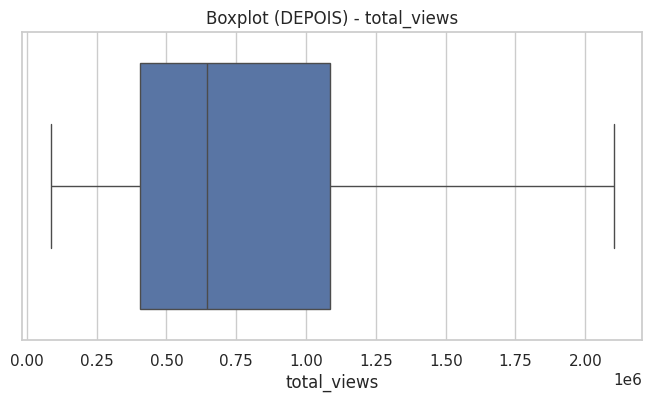

In [ ]:
# Boxplot depois (mesma coluna de exemplo)
plt.figure(figsize=(8,4))
sns.boxplot(x=df_capped[col_example])
plt.title(f'Boxplot (DEPOIS) - {col_example}')
plt.show()

**Q3** - As colunas com maior quantidade de outliers foram:

likes_count
comments_count
shares_count
channel_subscribers
previous_videos_count

**Q4** - Não.
Nenhum outlier foi removido. Em vez disso, utilizei capping pois:

Evitar perda de informação.
O dataset não é grande o suficiente para justificar remoções.
Capping mantém todos os registros, mas reduz influência dos valores extremos.

## 3. Parte 3 — Duplicatas
Remover duplicatas e registrar quantas foram removidas.

In [ ]:
# Verificar duplicatas antes
dups_before = df_capped.duplicated().sum()
print('Duplicatas antes:', dups_before)

# Remover duplicatas
df_nodup = df_capped.drop_duplicates().reset_index(drop=True)

dups_after = df_nodup.duplicated().sum()
print('Duplicatas depois:', dups_after)
print('Removidas:', int(dups_before - dups_after))

Duplicatas antes: 0
Duplicatas depois: 0
Removidas: 0


## 4. Parte 4 — Distribuições e Assimetria (Skewness)
Calcular skewness e aplicar transformações quando |skew| > 0.5.

In [ ]:
# Skewness antes
skew_values = df_nodup.select_dtypes(include=[np.number]).apply(lambda x: skew(x, nan_policy='omit')).sort_values(ascending=False)
skew_values_head = skew_values.head(60)
skew_values_head

,0
total_views,1.004105
channel_subscribers,0.167746
duration_minutes,0.126528
comments_count,0.058832
channel_age_months,0.053832
title_length,0.052156
tags_count,0.035960
shares_count,0.011574
likes_count,0.010157
playlist_adds,0.008103


In [ ]:
# Identificar colunas com |skew| > 0.5
skewed_cols = skew_values[abs(skew_values) > 0.5].index.tolist()
skewed_cols, len(skewed_cols)

(['total_views'], 1)

### Estratégia: aplicar `log1p` em colunas com skew positivo; manter/sqrt para casos especiais.

In [ ]:
df_trans = df_nodup.copy()
applied_transforms = {}

for col in skewed_cols:
    # aplicar log1p se todos os valores >= 0
    if (df_trans[col].dropna() >= 0).all():
        df_trans[col] = np.log1p(df_trans[col])
        applied_transforms[col] = 'log1p'
    else:
        # se existirem negativos, aplicar shift + log1p or sqrt; aqui usamos sqrt shift como fallback
        min_val = df_trans[col].min()
        shift = 0 if min_val >= 0 else abs(min_val) + 1
        df_trans[col] = np.sqrt(df_trans[col] + shift)
        applied_transforms[col] = 'sqrt_shift'

# Skewness após transformação
skew_after = df_trans.select_dtypes(include=[np.number]).apply(lambda x: skew(x, nan_policy='omit')).sort_values(ascending=False)
skew_after.head(60), applied_transforms

(channel_subscribers          0.167746
 duration_minutes             0.126528
 comments_count               0.058832
 channel_age_months           0.053832
 title_length                 0.052156
 tags_count                   0.035960
 shares_count                 0.011574
 likes_count                  0.010157
 playlist_adds                0.008103
 previous_videos_count        0.000119
 description_length          -0.007228
 avg_upload_frequency_days   -0.025355
 total_views                 -0.245073
 dtype: float64,
 {'total_views': 'log1p'})

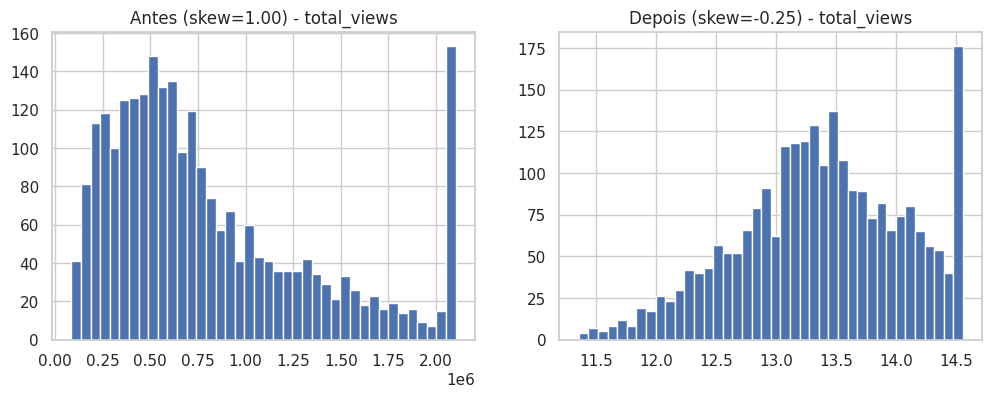

In [ ]:
# Plot exemplo antes/depois para a primeira coluna transformada (se existir)
if len(skewed_cols) > 0:
    col_plot = skewed_cols[0]
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].hist(df_nodup[col_plot].dropna(), bins=40)
    axes[0].set_title(f'Antes (skew={skew_values[col_plot]:.2f}) - {col_plot}')
    axes[1].hist(df_trans[col_plot].dropna(), bins=40)
    axes[1].set_title(f'Depois (skew={skew_after[col_plot]:.2f}) - {col_plot}')
    plt.show()
else:
    print('Nenhuma coluna com skew > 0.5 encontrada.')

## 5. Parte 5 — Encoding de Variáveis Categóricas
One-Hot Encoding para todas as colunas tipo object (nominais) com drop_first=True.

In [ ]:
#Ajustes antes do One-Hoting

df_adj = df_trans.copy()

# Remover ID que não deve ser encodado
if 'video_id' in df_adj.columns:
    df_adj = df_adj.drop(columns=['video_id'])

# upload_time deve ser tratado como categórica (não é timestamp)
df_adj.head()

,duration_minutes,title_length,description_length,tags_count,has_thumbnail_custom,video_quality,category,language,has_subtitles,channel_subscribers,...,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,shares_count,playlist_adds,promoted,upload_time,upload_day,total_views
0,3.0,53.0,589.0,34.0,Sim,720p,Fitness,Português,Não,474.0,...,406.0,9.0,2804.0,5269.0,2469.5,624.0,Não,Tarde,Sexta,14.559306
1,60.0,95.0,535.0,17.0,Não,720p,Culinária,Português,Não,899904.0,...,25.0,14.0,9634.0,9448.0,1679.0,894.0,Sim,Tarde,Sexta,13.486875
2,47.0,35.0,168.0,20.0,Não,1080p,Gaming,Espanhol,Não,761732.0,...,59.0,1.0,6943.0,34028.0,542.0,540.0,Não,Manhã,Seg-Qui,14.166489
3,8.0,12.0,260.0,4.0,Sim,1080p,Tecnologia,Português,Sim,154261.0,...,93.0,10.0,9427.0,42695.0,3096.0,188.0,Não,Madrugada,Sábado,12.706081
4,56.0,94.0,648.0,48.0,Não,720p,Vlogs,Espanhol,Não,843352.0,...,205.0,13.0,2993.0,40761.0,311.0,957.0,Não,Manhã,Domingo,13.800383


In [ ]:
cat_cols = df_adj.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas detectadas:", cat_cols)

df_enc = pd.get_dummies(df_adj, columns=cat_cols, drop_first=True)

print("Shape final depois do One-Hot:", df_enc.shape)
df_enc.head()


Colunas categóricas detectadas: ['has_thumbnail_custom', 'video_quality', 'category', 'language', 'has_subtitles', 'promoted', 'upload_time', 'upload_day']
Shape final depois do One-Hot: (2520, 44)


,duration_minutes,title_length,description_length,tags_count,channel_subscribers,channel_age_months,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,...,language_PORTUGUÊS,language_Português,has_subtitles_Sim,promoted_Sim,upload_time_Manhã,upload_time_Noite,upload_time_Tarde,upload_day_Seg-Qui,upload_day_Sexta,upload_day_Sábado
0,3.0,53.0,589.0,34.0,474.0,59.0,406.0,9.0,2804.0,5269.0,...,False,True,False,False,False,False,True,False,True,False
1,60.0,95.0,535.0,17.0,899904.0,59.0,25.0,14.0,9634.0,9448.0,...,False,True,False,True,False,False,True,False,True,False
2,47.0,35.0,168.0,20.0,761732.0,59.0,59.0,1.0,6943.0,34028.0,...,False,False,False,False,True,False,False,True,False,False
3,8.0,12.0,260.0,4.0,154261.0,84.0,93.0,10.0,9427.0,42695.0,...,False,True,True,False,False,False,False,False,False,True
4,56.0,94.0,648.0,48.0,843352.0,6.0,205.0,13.0,2993.0,40761.0,...,False,False,False,False,True,False,False,False,False,False


## 6. Parte 6 — Feature Engineering
Criar duas features e calcular correlação com o target `total_views` (ou outro target, se aplicável).

In [ ]:
import numpy as np

# Copiar o dataset OHE
df_feat = df_enc.copy()

# Feature 1: likes_per_share
# Interpretação: média de likes para cada compartilhamento.
df_feat['likes_per_share'] = df_feat['likes_count'] / (df_feat['shares_count'] + 1e-5)

# Feature 2: subs_per_month
# Interpretação: crescimento médio do canal por mês.
df_feat['subs_per_month'] = df_feat['channel_subscribers'] / (df_feat['channel_age_months'] + 1e-5)



In [ ]:
# =============================================================
# 2. Calcular correlação com o target (total_views)
# =============================================================

# Garantir que o target existe
target_col = 'total_views'

corr_1 = df_feat['likes_per_share'].corr(df_feat[target_col])
corr_2 = df_feat['subs_per_month'].corr(df_feat[target_col])

print("Correlação likes_per_share x total_views:", corr_1)
print("Correlação subs_per_month x total_views:", corr_2)

df_feat[['likes_per_share', 'subs_per_month', target_col]].head()

Correlação likes_per_share x total_views: 0.03349581054071576
Correlação subs_per_month x total_views: 0.1378197851816577


,likes_per_share,subs_per_month,total_views
0,2.133630,8.033897,14.559306
1,5.627159,15252.607584,13.486875
2,62.782287,12910.709676,14.166489
3,13.790375,1836.440258,12.706081
4,131.064304,140558.432403,13.800383


## 7. Parte 7 — Normalização (StandardScaler)
Padronizar todas as colunas numéricas.

In [ ]:
# Copiar para evitar modificar o original
df_scaled = df_feat.copy()

# Selecionar APENAS colunas numéricas para escalar
num_cols_final = df_scaled.select_dtypes(include=['int64', 'float64', 'bool']).columns

print("Colunas numéricas detectadas:", len(num_cols_final))
print(num_cols_final)

# Criar scaler
scaler = StandardScaler()

# Aplicar no dataframe
df_scaled[num_cols_final] = scaler.fit_transform(df_scaled[num_cols_final])

df_scaled.head()


Colunas numéricas detectadas: 46
Index(['duration_minutes', 'title_length', 'description_length', 'tags_count',
       'channel_subscribers', 'channel_age_months', 'previous_videos_count',
       'avg_upload_frequency_days', 'comments_count', 'likes_count',
       'shares_count', 'playlist_adds', 'total_views',
       'has_thumbnail_custom_Sim', 'video_quality_480p', 'video_quality_4K',
       'video_quality_4k', 'video_quality_720p', 'category_  Educação',
       'category_  Fitness', 'category_  Gaming', 'category_  Música',
       'category_  Tecnologia', 'category_  Vlogs', 'category_Culinária',
       'category_Educação', 'category_Fitness', 'category_Gaming',
       'category_Música', 'category_Tecnologia', 'category_Vlogs',
       'language_Espanhol', 'language_INGLÊS', 'language_Inglês',
       'language_PORTUGUÊS', 'language_Português', 'has_subtitles_Sim',
       'promoted_Sim', 'upload_time_Manhã', 'upload_time_Noite',
       'upload_time_Tarde', 'upload_day_Seg-Qui', 'uploa

,duration_minutes,title_length,description_length,tags_count,channel_subscribers,channel_age_months,previous_videos_count,avg_upload_frequency_days,comments_count,likes_count,...,has_subtitles_Sim,promoted_Sim,upload_time_Manhã,upload_time_Noite,upload_time_Tarde,upload_day_Seg-Qui,upload_day_Sexta,upload_day_Sábado,likes_per_share,subs_per_month
0,-1.637160,-0.054999,0.193606,0.637127,-1.634891,-0.012753,1.087937,-0.769581,-0.736755,-1.357659,...,-0.840334,-0.422696,-0.609756,-0.578572,1.802659,-0.552289,1.724750,-0.580405,-0.019925,-0.384847
1,1.611535,1.553480,-0.003821,-0.528060,1.310451,-0.012753,-1.519924,-0.196286,1.678099,-1.072161,...,-0.840334,2.365768,-0.609756,-0.578572,1.802659,-0.552289,1.724750,-0.580405,-0.019925,-0.103013
2,0.870605,-0.744347,-1.345596,-0.322439,0.857983,-0.012753,-1.287201,-1.686854,0.726654,0.607079,...,-0.840334,-0.422696,1.640001,-0.578572,-0.554736,1.810646,-0.579794,-0.580405,-0.019924,-0.146309
3,-1.352187,-1.625180,-1.009239,-1.419086,-1.131289,0.708441,-1.054479,-0.654922,1.604911,1.199186,...,1.190003,-0.422696,-0.609756,-0.578572,-0.554736,-0.552289,-0.579794,1.722935,-0.019925,-0.351044
4,1.383556,1.515183,0.409314,1.596692,1.125262,-1.541684,-0.287864,-0.310945,-0.669931,1.067060,...,-0.840334,-0.422696,1.640001,-0.578572,-0.554736,-0.552289,-0.579794,-0.580405,-0.019923,2.213580


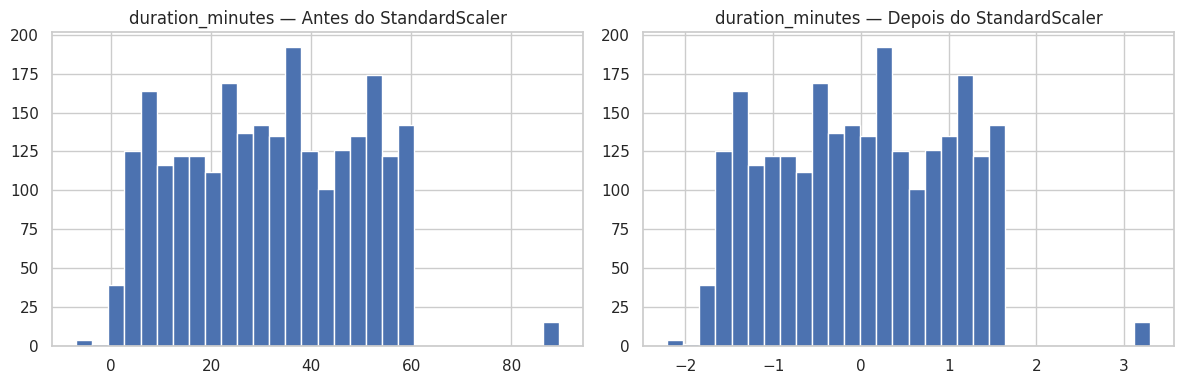

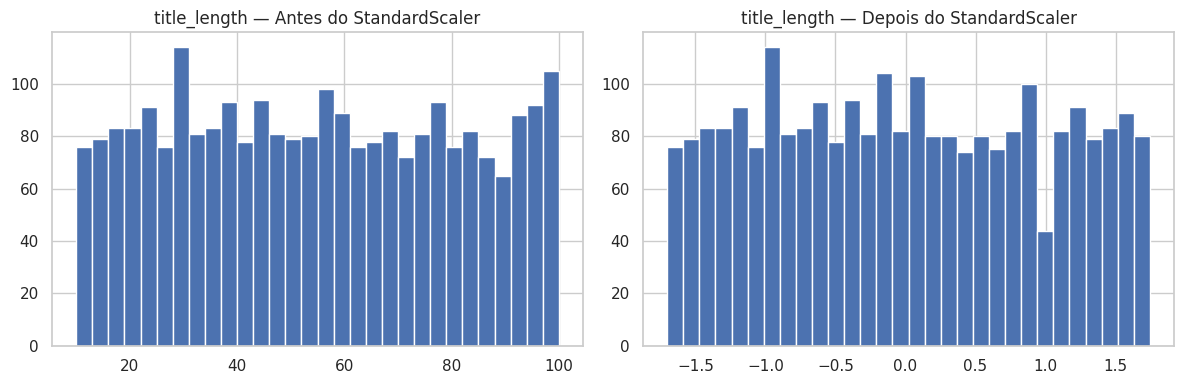

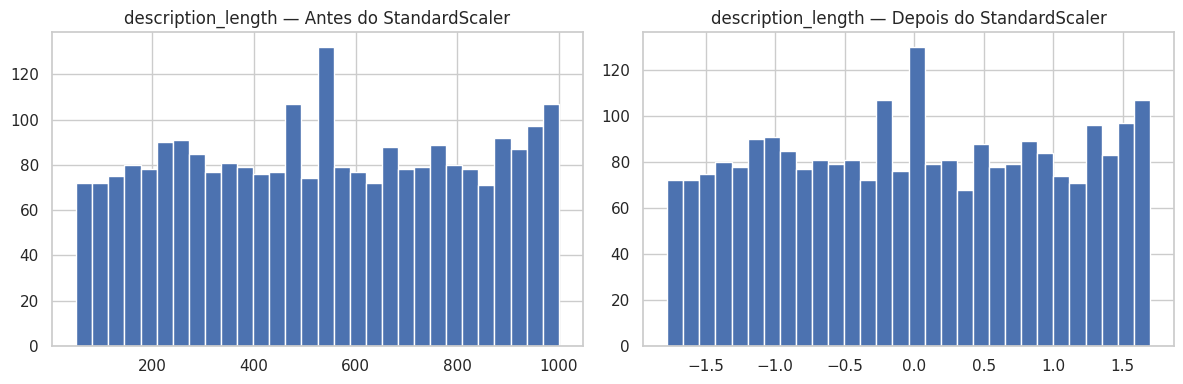

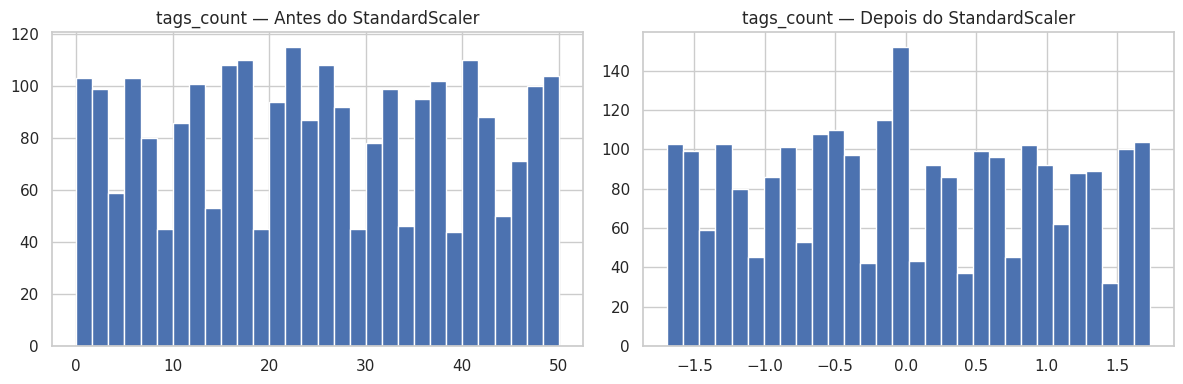

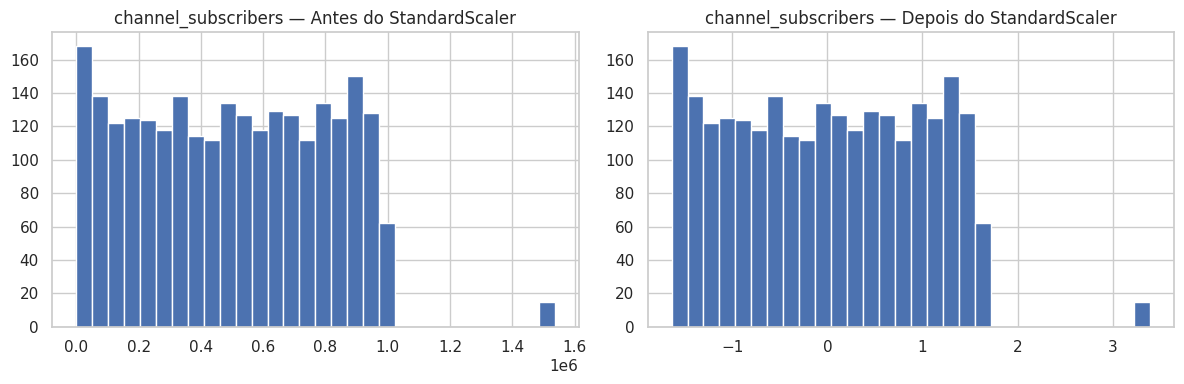

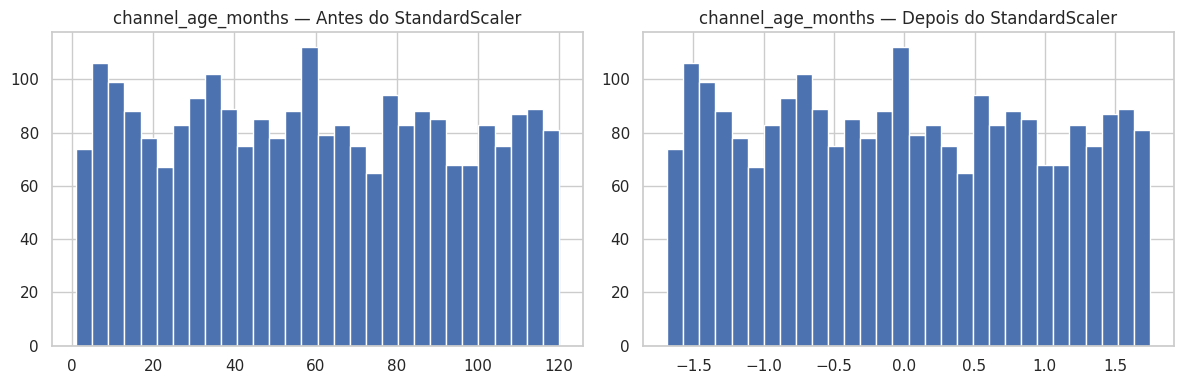

In [ ]:
#Gráfico do antes e depois da normalização:


cols_to_plot = df_scaled.select_dtypes(include=['float64','int64']).columns[:6]

for col in cols_to_plot:
    plt.figure(figsize=(12,4))

    # Antes
    plt.subplot(1,2,1)
    plt.hist(df_feat[col], bins=30)
    plt.title(f'{col} — Antes do StandardScaler')

    # Depois
    plt.subplot(1,2,2)
    plt.hist(df_scaled[col], bins=30)
    plt.title(f'{col} — Depois do StandardScaler')

    plt.tight_layout()
    plt.show()


In [ ]:
# Criar pasta models/ se não existir
import os
os.makedirs("models", exist_ok=True)

# Salvar o scaler treinado
joblib.dump(scaler, "models/scaler.pkl")

print("Scaler salvo com sucesso em models/scaler.pkl")


Scaler salvo com sucesso em models/scaler.pkl
